In [31]:
from pathlib import Path
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from scipy.spatial.distance import pdist, squareform
from nilearn.image import resample_to_img

base_dir = Path(r"D:\NTU_PSY\Documents\Patric_Asen_BrainHackProject")



##讀取特定subject的特定concepts trial index

def load_and_filter_conditions(
    base_dir,
    sub_id,
    targets,
    filename="subject_fMRI_nii/sub-01_condition_with_ratings.csv",
    verbose=True
):
    """
    Load + filter + sort fMRI condition table
    """

    # -------------------------
    # 1. load data
    # -------------------------
    path = base_dir / filename.replace("sub-01", sub_id)
    df = pd.read_csv(path)

    # -------------------------
    # 2. filter concepts
    # -------------------------
    df_selected = df[df["concept"].isin(targets)].copy()

    # -------------------------
    # 3. ordering
    # -------------------------
    df_selected["concept"] = pd.Categorical(
        df_selected["concept"],
        categories=targets,
        ordered=True
    )

    df_selected = (
        df_selected
        .sort_values(by=["concept"])
        .reset_index(drop=True)
    )

    # -------------------------
    # 4. print (optional)
    # -------------------------
    if verbose:
        print(f"\n[{sub_id}] total selected:", len(df_selected))
        print(df_selected["concept"].value_counts())
        print(df_selected)

    return df_selected



##由篩選過的trial index讀取部分concepts的fMRI trial

def extract_fmri_volumes_rowwise(
    df_sorted,
    base_dir,
    sub_id="sub-01",
    verbose=True
):
    """
    Extract fMRI volumes strictly following df row order.

    Returns
    -------
    selected_volumes : np.ndarray
        shape = (x, y, z, n_trials)
    """

    selected_volumes = []

    for row in df_sorted.itertuples():

        img_path = (
            base_dir /
            "subject_fMRI_nii" /
            sub_id /
            row.session /
            f"{sub_id}_{row.session}_run-{row.run:02d}_betas.nii"
        )

        img = nib.load(img_path)
        data = img.get_fdata()

        t = int(row.trial_idx)
        vol = data[..., t]

        selected_volumes.append(vol)

    selected_volumes = np.stack(selected_volumes, axis=-1)

    if verbose:
        print("Final shape:", selected_volumes.shape)
        print("mean:", np.mean(selected_volumes))
        print("std:", np.std(selected_volumes))
        print("min:", np.min(selected_volumes))
        print("max:", np.max(selected_volumes))

    return selected_volumes




##讀取並轉換atlas

reference_img = nib.load(base_dir / "subject_fMRI_nii\sub-01\ses-things01\sub-01_ses-things01_run-01_betas.nii")

atlas_img = nib.load(base_dir / "HCP_atlas\MNI_Glasser_HCP_v1.0.nii.gz")
atlas = nib.load(base_dir / "HCP_atlas\MNI_Glasser_HCP_v1.0.nii.gz").get_fdata()
print(atlas.shape)
print(atlas_img.affine)

##對atlas進行線性轉換，符合fMRI結構
print("beta shape:\n", reference_img.shape)
print("atlas shape:\n", atlas_img.shape)

print("beta affine:\n", reference_img.affine)
print("atlas affine:\n", atlas_img.affine)


atlas_rs = resample_to_img(atlas_img, reference_img, interpolation="nearest")
atlas = atlas_rs.get_fdata()

print("===resampled atlas info===")
print("resampled atlas shape:\n", atlas_rs.shape)
print("resampled atlas affine:\n", atlas_rs.affine)

##讀取atlas region名稱
tree = ET.parse(base_dir / "HCP_atlas\HCP-Multi-Modal-Parcellation-1.0.xml")
root = tree.getroot()

labels = {}

for label in root.find("data").findall("label"):
    idx = int(label.attrib["index"])
    name = label.text.strip()
    if name != "*.*.*.*.*":
        labels[idx] = name

print(labels)

df_labels = pd.DataFrame.from_dict(
    labels,
    orient="index",
    columns=["name"]
).reset_index().rename(columns={"index": "roi_id"})

def parse_name(name):
    try:
        hemi, region = name.split("_", 1)
        return hemi, region
    except:
        return None, name

df_labels[["hemi", "region"]] = df_labels["name"].apply(
    lambda x: pd.Series(parse_name(x))
)
print(df_labels.head())



##找尋特定roi id
def search_roi(df_labels, keyword):
    result = df_labels[
        df_labels["name"].str.contains(keyword, case=False, na=False)
    ].copy()

    return result.sort_values("roi_id")



##由已有的fMRI影像繪製特定roi的RDM

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

def compute_roi_rdm(
    atlas,
    selected_volumes,
    roi_ids,
    concept_labels,
    title="ROI RDM",
    metric="correlation",
    plot=True,
    mode="image"   # "image" or "concept"
):

    roi_mask = np.isin(atlas, roi_ids)
    roi_data = selected_volumes[roi_mask]
    trial_pattern = roi_data.T   # (trials, voxels)

    # =========================
    # IMAGE-BASED RDM (96 × 96)
    # =========================
    if mode == "image":

        rdm = squareform(
            pdist(trial_pattern, metric=metric)
        )

        n_concepts = 8
        n_per_concept = 12

    # =========================
    # CONCEPT-BASED RDM (8 × 8)
    # =========================
    elif mode == "concept":

        unique_concepts = np.unique(concept_labels)

        concept_patterns = []

        for c in unique_concepts:
            idx = np.where(np.array(concept_labels) == c)[0]
            concept_patterns.append(trial_pattern[idx].mean(axis=0))

        concept_patterns = np.vstack(concept_patterns)

        rdm = squareform(
            pdist(concept_patterns, metric=metric)
        )

    else:
        raise ValueError("mode must be 'image' or 'concept'")

    # =========================
    # PLOT
    # =========================
    if plot:

        fig, ax = plt.subplots(figsize=(7, 7))
        im = ax.imshow(rdm, interpolation="none")
        ax.set_title(title)

        # =========================
        # IMAGE LABELING (block-wise)
        # =========================
        if mode == "image":

            ticks = np.arange(0, n_concepts * n_per_concept, n_per_concept)
            labels = concept_labels

            ax.set_xticks(ticks)
            ax.set_yticks(ticks)

            ax.set_xticklabels(labels, rotation=45)
            ax.set_yticklabels(labels)


        # =========================
        # CONCEPT LABELING (8×8)
        # =========================
        elif mode == "concept":

            n_concepts = rdm.shape[0]
            labels = concept_labels

            ax.set_xticks(np.arange(n_concepts))
            ax.set_yticks(np.arange(n_concepts))

            ax.set_xticklabels(labels, rotation=45)
            ax.set_yticklabels(labels)

        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()

    return roi_mask, rdm

(256, 256, 256)
[[  -1.    0.    0.  128.]
 [   0.    1.    0. -146.]
 [   0.    0.    1. -108.]
 [   0.    0.    0.    1.]]
beta shape:
 (72, 91, 75, 92)
atlas shape:
 (256, 256, 256)
beta affine:
 [[  2.           0.           0.         -71.1632843 ]
 [  0.           2.           0.         -80.94287109]
 [  0.           0.           2.         -68.46676636]
 [  0.           0.           0.           1.        ]]
atlas affine:
 [[  -1.    0.    0.  128.]
 [   0.    1.    0. -146.]
 [   0.    0.    1. -108.]
 [   0.    0.    0.    1.]]
===resampled atlas info===
resampled atlas shape:
 (72, 91, 75)
resampled atlas affine:
 [[  2.           0.           0.         -71.1632843 ]
 [  0.           2.           0.         -80.94287109]
 [  0.           0.           2.         -68.46676636]
 [  0.           0.           0.           1.        ]]
{1: 'L_V1', 2: 'L_MST', 3: 'L_V6', 4: 'L_V2', 5: 'L_V3', 6: 'L_V4', 7: 'L_V8', 8: 'L_4', 9: 'L_3b', 10: 'L_FEF', 11: 'L_PEF', 12: 'L_55b', 13: 'L_

In [11]:
affordance_candidates_list = ['calculator', 'typewriter', 'pencil', 'spoon', 'tongs', 'tweezers', 'gearshift', 'joystick']
concepts_label = affordance_candidates_list
    

In [3]:
df_sub01 = load_and_filter_conditions(
    base_dir=base_dir,
    sub_id="sub-01",
    targets=affordance_candidates_list
)


[sub-01] total selected: 96
concept
calculator    12
typewriter    12
pencil        12
spoon         12
tongs         12
tweezers      12
gearshift     12
joystick      12
Name: count, dtype: int64
                   image_filename       session  run  trial_idx subject  \
0   calculator/calculator_09s.jpg  ses-things12   10         26  sub-01   
1   calculator/calculator_10n.jpg  ses-things04    4          9  sub-01   
2   calculator/calculator_06s.jpg  ses-things05    3         76  sub-01   
3   calculator/calculator_11s.jpg  ses-things06    4          7  sub-01   
4   calculator/calculator_07s.jpg  ses-things07    1         87  sub-01   
..                            ...           ...  ...        ...     ...   
91      joystick/joystick_05s.jpg  ses-things11    2         70  sub-01   
92      joystick/joystick_06s.jpg  ses-things05   10          0  sub-01   
93      joystick/joystick_04s.jpg  ses-things02    8         36  sub-01   
94      joystick/joystick_08s.jpg  ses-things10    

In [4]:
selected_volumes = extract_fmri_volumes_rowwise(
    df_sorted=df_sub01,
    base_dir=base_dir,
    sub_id="sub-01"
)

Final shape: (72, 91, 75, 96)
mean: 0.0007791536835514501
std: 0.04191531677697121
min: -0.4953700304031372
max: 0.5663968920707703


# Affordance ROI

In [5]:
search_roi(df_labels, "AIP")

,roi_id,name,hemi,region
116,117,L_AIP,L,AIP
296,1117,R_AIP,R,AIP


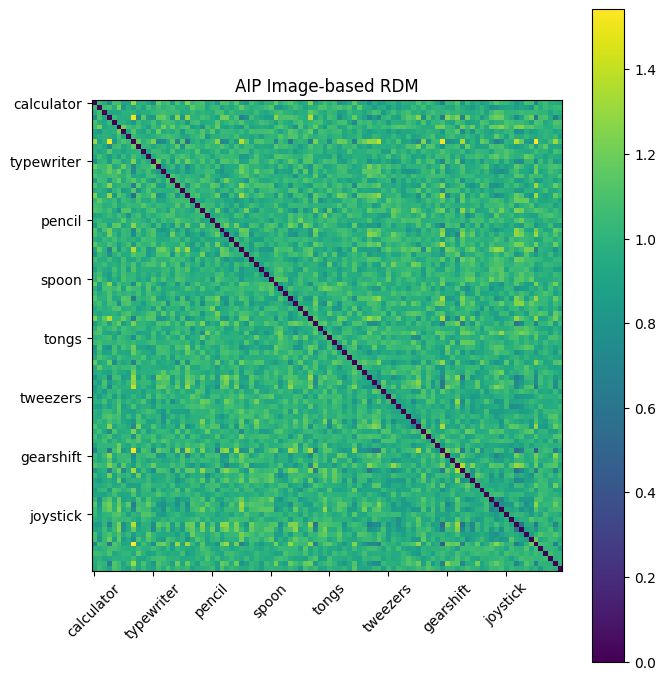

In [32]:
AIP_ids = [
    117, 1117
]

_, AIP_rdm_img = compute_roi_rdm(
    atlas,
    selected_volumes,
    AIP_ids,
    concepts_label,
    title="AIP Image-based RDM",
    mode="image"
)

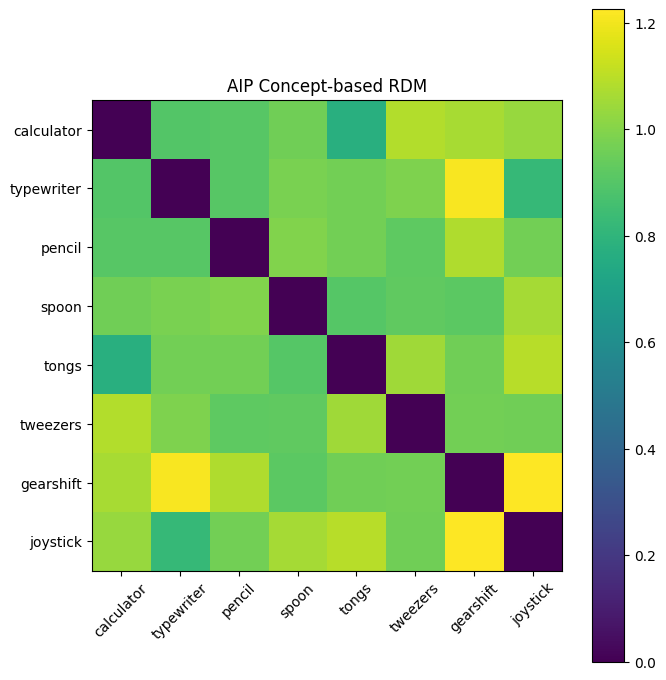

In [42]:
_, AIP_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    AIP_ids,
    concepts_label,
    title="AIP Concept-based RDM",
    mode="concept"
)

In [34]:
search_roi(df_labels, "PF")

,roi_id,name,hemi,region
104,105,L_PFcm,L,PFcm
115,116,L_PFt,L,PFt
146,147,L_PFop,L,PFop
147,148,L_PF,L,PF
148,149,L_PFm,L,PFm
284,1105,R_PFcm,R,PFcm
295,1116,R_PFt,R,PFt
326,1147,R_PFop,R,PFop
327,1148,R_PF,R,PF
328,1149,R_PFm,R,PFm


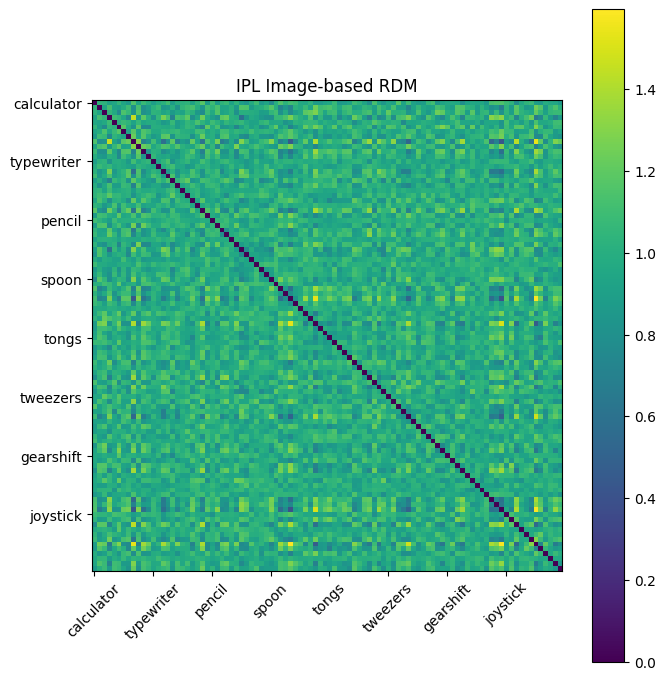

In [43]:
IPL_ids = [
    105, 116, 147, 148, 149
]

_, IPL_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    IPL_ids,
    concepts_label,
    title="IPL Image-based RDM",
    mode="image"
)

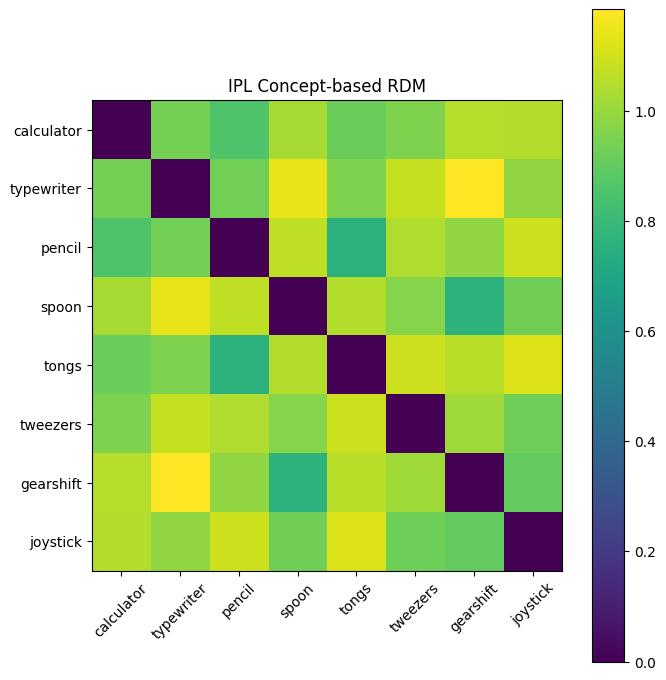

In [44]:
_, IPL_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    IPL_ids,
    concepts_label,
    title="IPL Concept-based RDM",
    mode="concept"
)

In [45]:
search_roi(df_labels, "6V")

,roi_id,name,hemi,region
55,56,L_6v,L,6v
82,83,L_p9-46v,L,p9-46v
84,85,L_a9-46v,L,a9-46v
235,1056,R_6v,R,6v
262,1083,R_p9-46v,R,p9-46v
264,1085,R_a9-46v,R,a9-46v


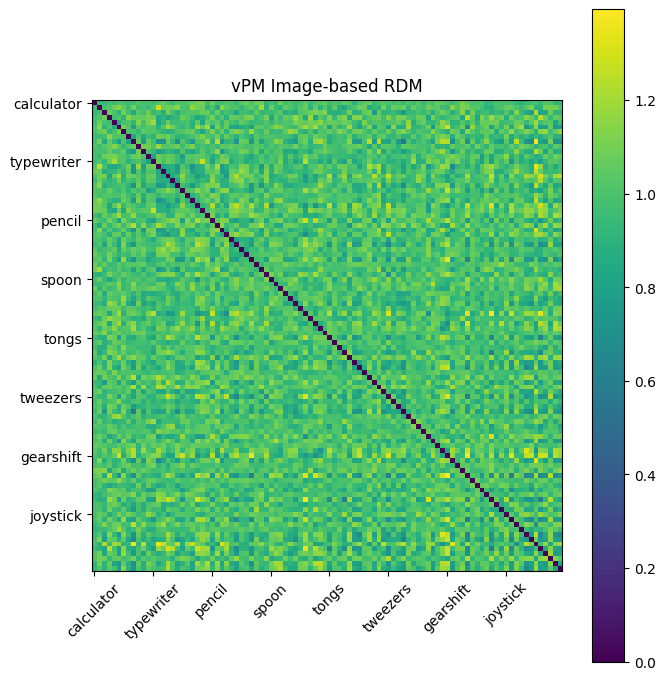

In [46]:
vPM_ids = [
    56, 1056
]

_, vPM_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    vPM_ids,
    concepts_label,
    title="vPM Image-based RDM",
    mode="image"
)

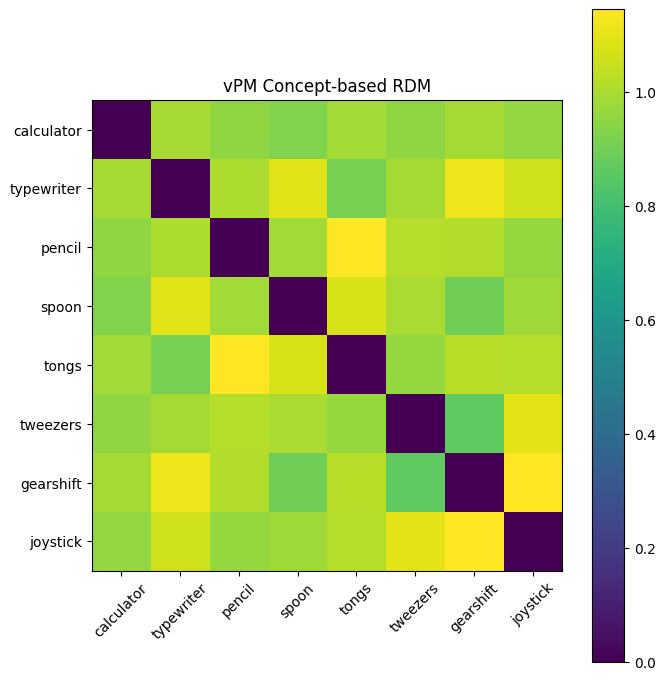

In [47]:
_, vPM_rdm_concept = compute_roi_rdm(
    atlas,
    selected_volumes,
    vPM_ids,
    concepts_label,
    title="vPM Concept-based RDM",
    mode="concept"
)

In [48]:
search_roi(df_labels, "AIP")

,roi_id,name,hemi,region
116,117,L_AIP,L,AIP
296,1117,R_AIP,R,AIP


In [49]:
search_roi(df_labels, "AIP")

,roi_id,name,hemi,region
116,117,L_AIP,L,AIP
296,1117,R_AIP,R,AIP


In [50]:
search_roi(df_labels, "AIP")

,roi_id,name,hemi,region
116,117,L_AIP,L,AIP
296,1117,R_AIP,R,AIP


# Object/Semantic ROI

In [51]:
search_roi(df_labels, "AIP")

,roi_id,name,hemi,region
116,117,L_AIP,L,AIP
296,1117,R_AIP,R,AIP
